<a href="https://colab.research.google.com/github/manaswi92/SCT_DS_1/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os


zip_file_path = '/content/API_SP.POP.TOTL_DS2_en_csv_v2_406129.zip'
output_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

file_path = '/content/API_SP.POP.TOTL_DS2_en_csv_v2_406129.csv'
meta_path = '/content/Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_406129.csv'

df = pd.read_csv(file_path, skiprows=4)
meta_df = pd.read_csv(meta_path)

countries = meta_df[meta_df['Region'].notna()]['Country Code'].unique()

country_pop_2023 = df[df['Country Code'].isin(countries)][['Country Name', '2023']].dropna()

top_10_countries = country_pop_2023.sort_values(by='2023', ascending=False).head(10)

In [ ]:
global_population_2023 = country_pop_2023['2023'].sum()
top_10_countries['Percentage of Global Population'] = (top_10_countries['2023'] / global_population_2023) * 100
display(top_10_countries[['Country Name', '2023', 'Percentage of Global Population']])

,Country Name,2023,Percentage of Global Population
109,India,1.438070e+09,17.884915
40,China,1.410710e+09,17.544650
251,United States,3.368062e+08,4.188776
106,Indonesia,2.811901e+08,3.497091
184,Pakistan,2.475045e+08,3.078152
174,Nigeria,2.278829e+08,2.834124
29,Brazil,2.111407e+08,2.625905
20,Bangladesh,1.714670e+08,2.132492
202,Russian Federation,1.438261e+08,1.788730
154,Mexico,1.297398e+08,1.613541


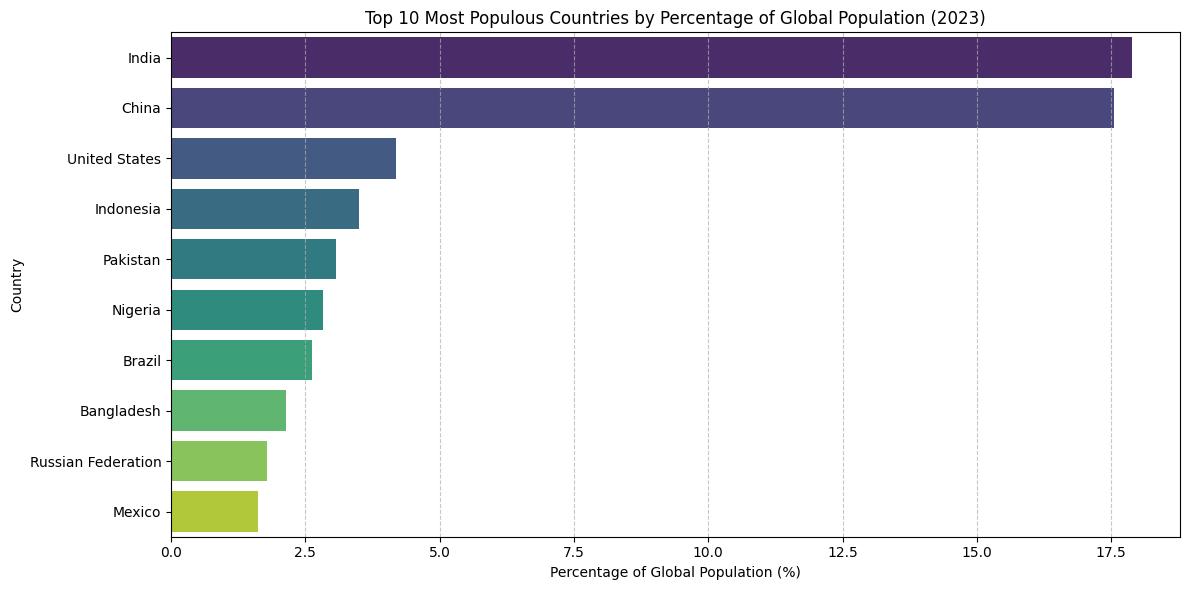

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Percentage of Global Population', y='Country Name', data=top_10_countries, hue='Country Name', palette='viridis', legend=False)
plt.title('Top 10 Most Populous Countries by Percentage of Global Population (2023)')
plt.xlabel('Percentage of Global Population (%)')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()